# RL Group Project: Configuration B
## Clinical Treatment Optimisation: Sepsis ICU Management — Continuous Observations

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This notebook covers **Configuration B**, where the agent operates in the full continuous-observation ICU-Sepsis environment with three clinical reality wrappers injecting realistic failure modes.

---
### Group Members

Name of the Group: Group AB

```
Student 1: Andreea Roica
Student 2: Marisa Esteves
Student 3: Miguel Caramelo
Student 4: Oliver Kain
```

## 0. Setup & Imports

In [1]:
# Install dependencies (run once)
# !pip install icu-sepsis numpy pandas matplotlib seaborn torch gymnasium

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # to avoid kernel crashes on some platforms
import random

import torch

# Classes and functions for Configuration B
import rl_configB_functions
from rl_configB_functions import (
    EvalMetricsB, evaluate_policy_b,
    QNetwork, ReplayBuffer, DQNAgent,
    train_dqn, sample_params_b,
    moving_average, dqn_convergence_episode,
    SEED, N_OBS, N_ACTIONS, GAMMA,
)

import importlib
importlib.reload(rl_configB_functions)

# Clinical reality wrappers and environment factory
from envs.wrappers import (
    EpisodicNoisyObsEnv,
    EpisodicMissingObsEnv,
    AcuteEventEnv,
    make_clinical_env,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

print(f'Config B | Obs dim: {N_OBS} | Actions: {N_ACTIONS} | γ = {GAMMA}')
print(f'PyTorch version : {torch.__version__}')
print('Setup complete!')

Config B | Obs dim: 47 | Actions: 25 | γ = 1.0
PyTorch version : 2.12.0+cpu
Setup complete!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


---
## 1. Explore the Clinical Environment

Before designing any algorithm, we inspect the environment structure, understand the observation space, and establish a random-policy baseline.  
This section also characterises the three clinical reality wrappers individually, so their impact on observed performance is understood before training begins.

In [2]:
# Instantiate and inspect the clinical environment
env = make_clinical_env()
obs, info = env.reset(seed=SEED)

print('Clinical ICU-Sepsis environment')
print(f'  Observation space : {env.observation_space}')
print(f'  Action space      : {env.action_space}')
print(f'  Obs shape         : {obs.shape}  dtype={obs.dtype}')
print(f'  Info keys         : {list(info.keys())}')
print()
print('Wrapper stack (outermost first):')
e = env
while hasattr(e, 'env'):
    print(f'  {type(e).__name__}')
    e = e.env
print(f'  {type(e).__name__}  ← base environment')
env.close()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Clinical ICU-Sepsis environment
  Observation space : Box(-inf, inf, (47,), float32)
  Action space      : Discrete(25)
  Obs shape         : (47,)  dtype=float32
  Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']

Wrapper stack (outermost first):
  AcuteEventEnv
  EpisodicMissingObsEnv
  EpisodicNoisyObsEnv
  ContinuousICUSepsisEnv  ← base environment


In [3]:
# Inspect the 47 physiological feature names
from envs.continuous_sepsis_env import FEATURE_NAMES

feat_df = pd.DataFrame({'index': range(len(FEATURE_NAMES)), 'feature': FEATURE_NAMES})
print(f'Physiological feature vector ({len(FEATURE_NAMES)} dimensions):')
print(feat_df.to_string(index=False))

Physiological feature vector (47 dimensions):
 index        feature
     0        Albumin
     1            ALP
     2            ALT
     3            AST
     4      Bilirubin
     5            BUN
     6       Chloride
     7     Creatinine
     8   Diastolic_BP
     9     Fibrinogen
    10           FiO2
    11            GCS
    12        Glucose
    13           HCO3
    14     Hemoglobin
    15            INR
    16        Lactate
    17          MgSO4
    18        Mean_BP
    19      Potassium
    20            PTT
    21          PaCO2
    22           PaO2
    23      Platelets
    24            RBC
    25           SOFA
    26         Sodium
    27    Systolic_BP
    28    Temperature
    29       Troponin
    30   Urine_Output
    31            WBC
    32         Weight
    33             Ca
    34        Heparin
    35             HR
    36      Na_Bicarb
    37        Insulin
    38 Norepinephrine
    39       Propofol
    40    Vasopressin
    41       Dopamine
    42  

In [4]:
# Random baseline on the clinical environment (1000 episodes)
np.random.seed(SEED)

clinical_rand_returns = []
noisy_returns, clean_returns     = [], []
missing_returns, nomiss_returns  = [], []
acute_episodes = 0

env_eval = make_clinical_env()
for ep in range(1000):
    obs, info = env_eval.reset(seed=np.random.randint(100_000))
    total_r, done = 0.0, False
    ep_noisy   = info.get('noisy_episode', False)
    ep_missing = info.get('missing_features') is not None
    ep_acute   = False

    while not done:
        obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
        total_r += r
        done = te or tr
        if info.get('acute_event', False):
            ep_acute = True

    clinical_rand_returns.append(total_r)
    (noisy_returns   if ep_noisy   else clean_returns).append(total_r)
    (missing_returns if ep_missing else nomiss_returns).append(total_r)
    if ep_acute:
        acute_episodes += 1

env_eval.close()

clinical_rand_mean   = float(np.mean(clinical_rand_returns))
clinical_rand_surv   = float(np.mean(np.array(clinical_rand_returns) > 0))

print('=== Random Baseline: Clinical Environment (1000 episodes) ===')
print(f'Overall mean return   : {clinical_rand_mean:.4f}')
print(f'Overall survival rate : {clinical_rand_surv:.1%}')
print()
print('Stratified by wrapper:')
print(f'  Noisy episodes     ({len(noisy_returns):3d} eps) : return = {np.mean(noisy_returns):.4f}  surv = {np.mean(np.array(noisy_returns)>0):.1%}')
print(f'  Clean episodes     ({len(clean_returns):3d} eps) : return = {np.mean(clean_returns):.4f}  surv = {np.mean(np.array(clean_returns)>0):.1%}')
print(f'  Missing obs eps    ({len(missing_returns):3d} eps) : return = {np.mean(missing_returns):.4f}  surv = {np.mean(np.array(missing_returns)>0):.1%}')
print(f'  Complete obs eps   ({len(nomiss_returns):3d} eps) : return = {np.mean(nomiss_returns):.4f}  surv = {np.mean(np.array(nomiss_returns)>0):.1%}')
print(f'  Episodes with acute event : {acute_episodes} ({acute_episodes/10:.1f}%)')
print()
print('All Config B algorithms must beat this random baseline.')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Random Baseline: Clinical Environment (1000 episodes) ===
Overall mean return   : 0.5562
Overall survival rate : 64.7%

Stratified by wrapper:
  Noisy episodes     (140 eps) : return = 0.5195  surv = 60.7%
  Clean episodes     (860 eps) : return = 0.5622  surv = 65.3%
  Missing obs eps    (138 eps) : return = 0.6034  surv = 67.4%
  Complete obs eps   (862 eps) : return = 0.5486  surv = 64.3%
  Episodes with acute event : 74 (7.4%)

All Config B algorithms must beat this random baseline.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


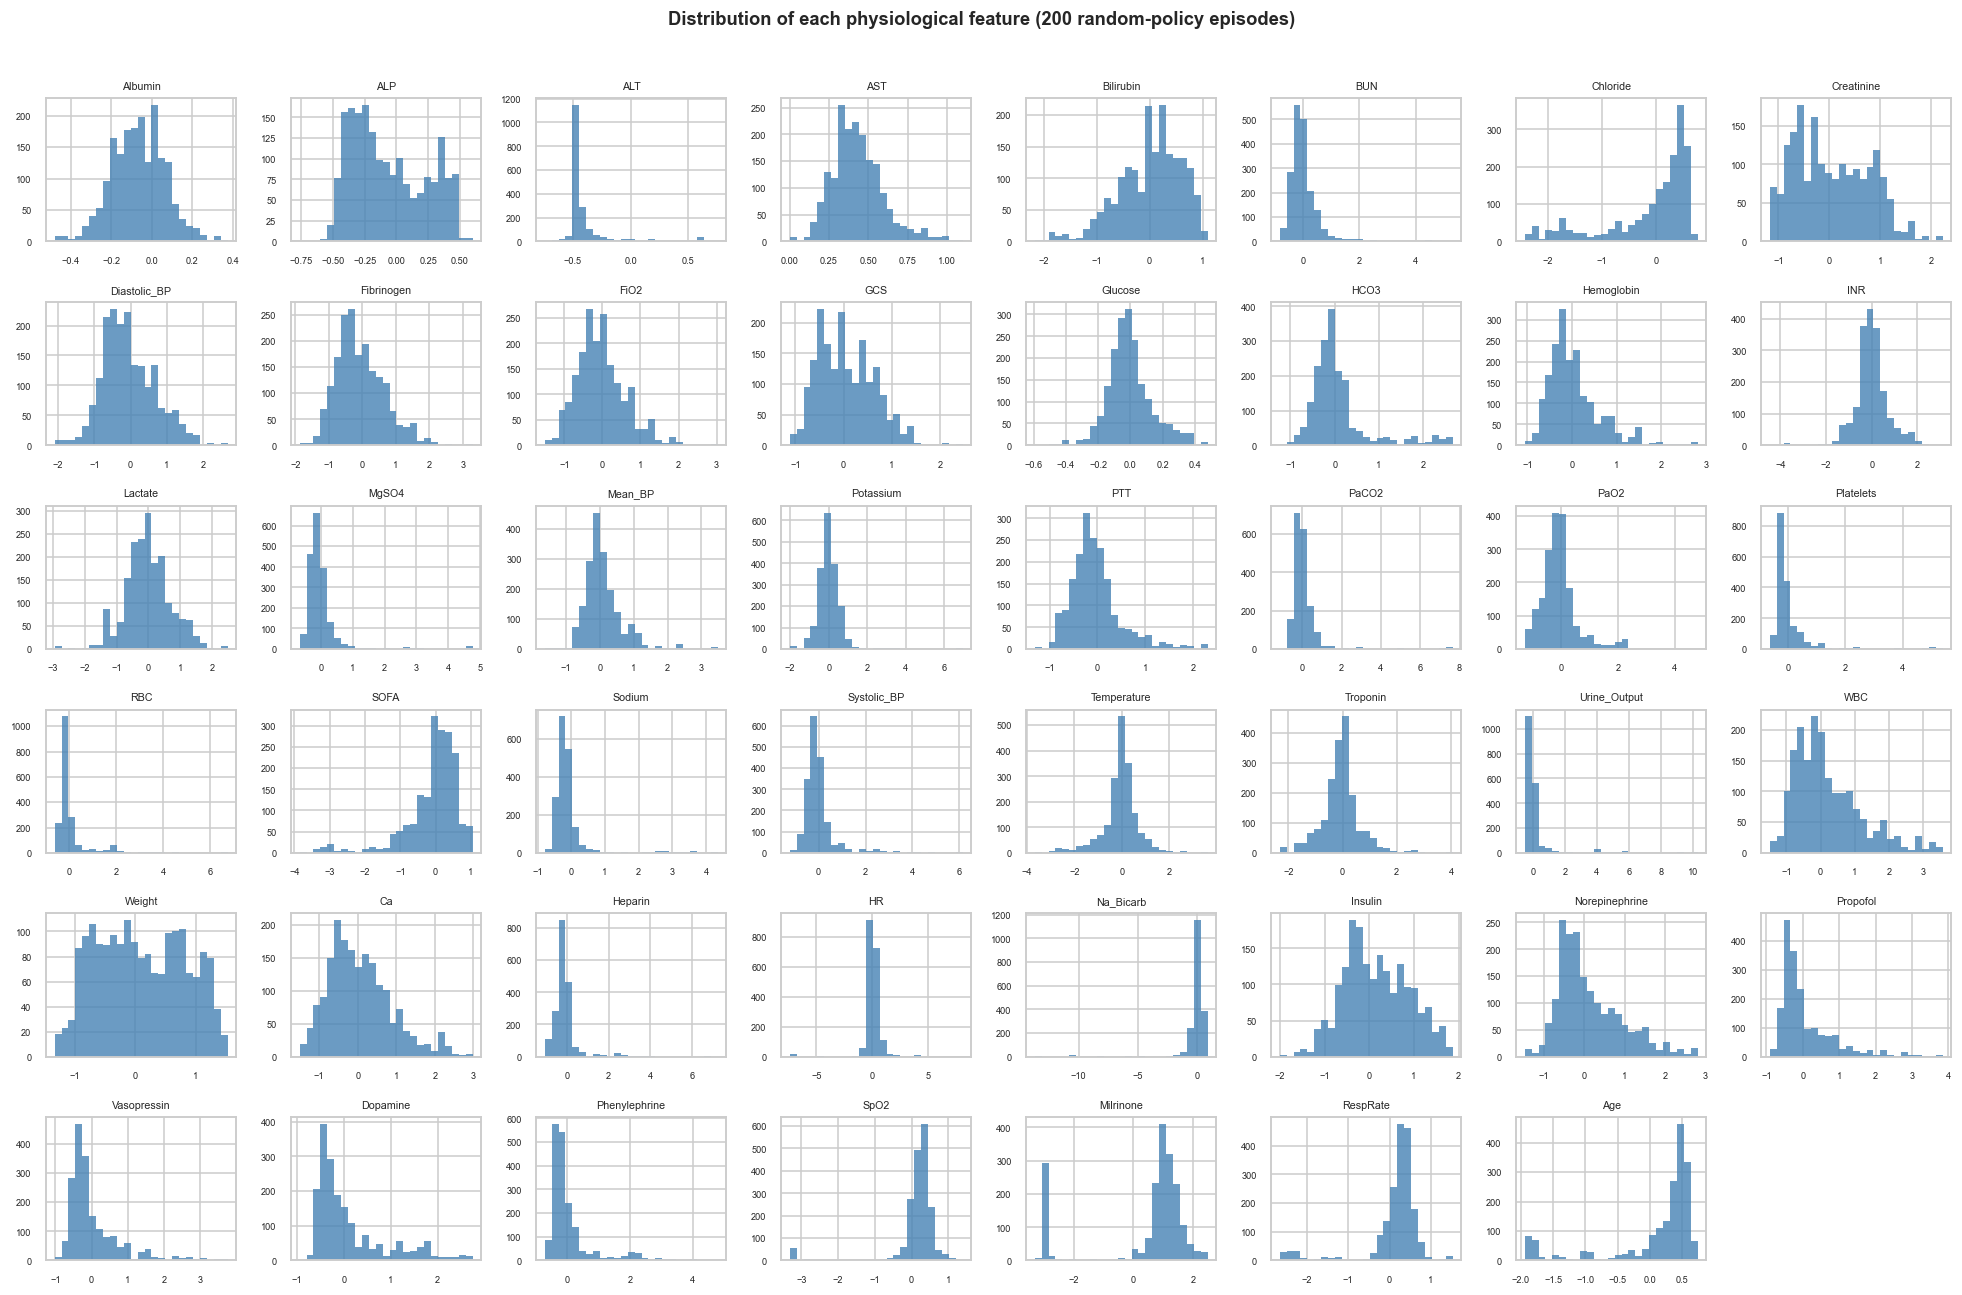

In [5]:
# Visualise the observation distribution under a random policy
np.random.seed(SEED)
env_vis = make_clinical_env()
all_obs = []

for _ in range(200):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        all_obs.append(obs.copy())
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()

obs_arr = np.array(all_obs)   # shape: (total_steps, 47)

fig, axes = plt.subplots(6, 8, figsize=(18, 12))
axes = axes.flatten()
for i, feat in enumerate(FEATURE_NAMES):
    axes[i].hist(obs_arr[:, i], bins=25, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(feat, fontsize=7)
    axes[i].tick_params(labelsize=6)
# Hide any spare subplots
for j in range(len(FEATURE_NAMES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of each physiological feature (200 random-policy episodes)', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'{PLOTS_DIR}/configB_obs_distribution.png', bbox_inches='tight')
plt.show()

---
# Config B — Deep Q-Network (DQN)

With a 47-dimensional continuous observation space, a tabular Q-table is no longer feasible: it would need one entry per unique float vector — effectively infinite.  
We therefore replace the table with a **neural network** that approximates $Q(s, a)$ for all actions simultaneously given a continuous state vector.

### Why DQN?

DQN (Mnih et al., 2015) extends Q-learning to continuous state spaces using a feedforward network as the function approximator. Two key stabilisation mechanisms address the pathologies that arise when neural networks are trained on correlated, non-stationary targets:

1. **Experience Replay**: transitions $(s, a, r, s')$ are stored in a buffer and sampled uniformly at random. This breaks the temporal correlation between consecutive training samples that would otherwise cause the network to overfit to recent experience.

2. **Target Network**: a separate network, periodically synchronised from the main network, is used to compute the bootstrap target $y = r + \gamma \max_{a'} Q_{\text{target}}(s', a')$. This prevents the moving-target problem where both the prediction and the target change simultaneously.

We further adopt **Double DQN** (van Hasselt et al., 2016), which decouples action selection from action evaluation:
$$y = r + \gamma \, Q_{\text{target}}\!\left(s',\, \arg\max_{a'} Q_{\text{online}}(s', a')\right)$$
This reduces the overestimation bias inherent in vanilla DQN and is well suited to the sparse, delayed reward structure of ICU-Sepsis.

## Hyperparameter Search

DQN performance is sensitive to the learning rate, exploration schedule, and network capacity. We perform a random search over the parameter grid below, using a reduced number of training episodes per trial for computational efficiency. The top-3 configurations are then re-evaluated across multiple random seeds.

In [6]:
param_grid_b = {
    'lr':            [1e-4, 5e-4, 1e-3],
    'epsilon_decay': [0.990, 0.995, 0.999],
    'epsilon_min':   [0.01, 0.05, 0.10],
    'batch_size':    [32, 64, 128],
    'hidden1':       [64, 128, 256],
    'hidden2':       [64, 128, 256],
}

In [8]:
search_results_b = []
N_TRIALS   = 15
TRIAL_EPS  = 1000   # reduced budget for the screening phase

selected_params_b = []
while len(selected_params_b) < N_TRIALS:
    random_params = sample_params_b(param_grid_b)
    if random_params not in selected_params_b:
        selected_params_b.append(random_params)

for trial, params in enumerate(selected_params_b):
    print(f'\nTrial {trial+1}/{N_TRIALS}')
    print(params)

    metrics = train_dqn(
        n_episodes    = TRIAL_EPS,
        lr            = params['lr'],
        epsilon_decay = params['epsilon_decay'],
        epsilon_min   = params['epsilon_min'],
        batch_size    = params['batch_size'],
        hidden1       = params['hidden1'],
        hidden2       = params['hidden2'],
        seed          = SEED,
    )

    results = evaluate_policy_b(metrics['agent']).summary()

    row = {
        **params,
        'mean_return':       results['mean_return'],
        'survival_rate':     results['survival_rate'],
        'mean_length':       results['mean_length'],
        'train_mean_return': np.mean(metrics['returns'][-200:]),
        'final_epsilon':     metrics['epsilons'][-1],
    }
    search_results_b.append(row)

    print(
        f"Return: {results['mean_return']:.4f} | "
        f"Survival: {results['survival_rate']:.2%} | "
        f"Mean length: {results['mean_length']:.2f}"
    )


Trial 1/15
{'lr': 0.0001, 'epsilon_decay': 0.99, 'epsilon_min': 0.01, 'batch_size': 64, 'hidden1': 128, 'hidden2': 256}
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Return: 0.6099 | Survival: 69.30% | Mean length: 8.82

Trial 2/15
{'lr': 0.001, 'epsilon_decay': 0.99, 'epsilon_min': 0.01, 'batch_size': 128, 'hidden1': 256, 'hidden2': 128}
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Return: 0.5391 | Survival: 63.60% | Mean length: 9.76

Trial 3/15
{'lr': 0.001, 'epsilon_decay': 0.995, 'epsilon_min': 0.01, 'batch_size': 64, 'hidden1': 128, 'hidden2': 128}
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → m

In [9]:
results_df_b = pd.DataFrame(search_results_b)
results_df_b.sort_values('mean_return', ascending=False).head(10)

,lr,epsilon_decay,epsilon_min,batch_size,hidden1,hidden2,mean_return,survival_rate,mean_length,train_mean_return,final_epsilon
0,0.0001,0.990,0.01,64,128,256,0.609855,0.693,8.822,0.540250,0.01
11,0.0001,0.990,0.01,64,64,256,0.605485,0.691,9.218,0.578150,0.01
8,0.0001,0.990,0.05,128,64,64,0.596590,0.681,9.228,0.560462,0.05
2,0.0010,0.995,0.01,64,128,128,0.578928,0.666,9.679,0.652087,0.01
13,0.0001,0.995,0.10,64,256,64,0.576932,0.671,9.388,0.587350,0.10
14,0.0005,0.995,0.10,64,64,128,0.575705,0.666,9.616,0.541738,0.10
3,0.0005,0.990,0.10,64,128,128,0.574900,0.665,8.911,0.524600,0.10
9,0.0010,0.995,0.01,64,256,128,0.570805,0.666,9.601,0.563462,0.01
10,0.0010,0.995,0.01,128,256,256,0.557053,0.648,9.513,0.606825,0.01
7,0.0001,0.990,0.05,32,64,64,0.552397,0.652,10.081,0.559287,0.05


Initial screening is single-seed, so variance is present. The top-3 configurations by mean return are validated across multiple seeds before choosing a final configuration.

In [10]:
# Select the top-3 trials by mean return for multi-seed validation
top3_idx = results_df_b['mean_return'].nlargest(3).index.tolist()

candidate_configs_b = []
for idx in top3_idx:
    row = results_df_b.iloc[idx]
    candidate_configs_b.append({
        'config_id':     idx,
        'lr':            row['lr'],
        'epsilon_decay': row['epsilon_decay'],
        'epsilon_min':   row['epsilon_min'],
        'batch_size':    int(row['batch_size']),
        'hidden1':       int(row['hidden1']),
        'hidden2':       int(row['hidden2']),
    })

print('Top-3 candidate configurations:')
for c in candidate_configs_b:
    print(c)

Top-3 candidate configurations:
{'config_id': 0, 'lr': np.float64(0.0001), 'epsilon_decay': np.float64(0.99), 'epsilon_min': np.float64(0.01), 'batch_size': 64, 'hidden1': 128, 'hidden2': 256}
{'config_id': 11, 'lr': np.float64(0.0001), 'epsilon_decay': np.float64(0.99), 'epsilon_min': np.float64(0.01), 'batch_size': 64, 'hidden1': 64, 'hidden2': 256}
{'config_id': 8, 'lr': np.float64(0.0001), 'epsilon_decay': np.float64(0.99), 'epsilon_min': np.float64(0.05), 'batch_size': 128, 'hidden1': 64, 'hidden2': 64}


In [11]:
MULTI_SEEDS_B = [1, 2, 3, 4, 5]
FULL_EPS      = 3000  # full training budget for multi-seed runs

all_results_b = []

for config in candidate_configs_b:
    print('\n' + '='*60)
    print(f"Evaluating Config {config['config_id']}")
    print(config)

    for seed in MULTI_SEEDS_B:
        print(f'  Seed {seed}')

        metrics = train_dqn(
            n_episodes    = FULL_EPS,
            lr            = config['lr'],
            epsilon_decay = config['epsilon_decay'],
            epsilon_min   = config['epsilon_min'],
            batch_size    = config['batch_size'],
            hidden1       = config['hidden1'],
            hidden2       = config['hidden2'],
            seed          = seed,
        )

        results = evaluate_policy_b(metrics['agent'], seed=seed).summary()

        row = {
            'config_id':     config['config_id'],
            'seed':          seed,
            **{k: config[k] for k in ['lr', 'epsilon_decay', 'epsilon_min', 'batch_size', 'hidden1', 'hidden2']},
            'mean_return':   results['mean_return'],
            'survival_rate': results['survival_rate'],
            'mean_length':   results['mean_length'],
        }
        all_results_b.append(row)

multi_seed_df_b = pd.DataFrame(all_results_b)
multi_seed_df_b


Evaluating Config 0
{'config_id': 0, 'lr': np.float64(0.0001), 'epsilon_decay': np.float64(0.99), 'epsilon_min': np.float64(0.01), 'batch_size': 64, 'hidden1': 128, 'hidden2': 256}
  Seed 1
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  Seed 2
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  Seed 3
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  Seed 4
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_

,config_id,seed,lr,epsilon_decay,epsilon_min,batch_size,hidden1,hidden2,mean_return,survival_rate,mean_length
0,0,1,0.0001,0.99,0.01,64,128,256,0.559147,0.644,9.078
1,0,2,0.0001,0.99,0.01,64,128,256,0.582578,0.674,9.399
2,0,3,0.0001,0.99,0.01,64,128,256,0.591840,0.667,8.987
3,0,4,0.0001,0.99,0.01,64,128,256,0.575048,0.667,9.416
4,0,5,0.0001,0.99,0.01,64,128,256,0.568605,0.654,9.551
5,11,1,0.0001,0.99,0.01,64,64,256,0.573405,0.658,9.526
6,11,2,0.0001,0.99,0.01,64,64,256,0.559767,0.645,9.623
7,11,3,0.0001,0.99,0.01,64,64,256,0.572355,0.657,9.596
8,11,4,0.0001,0.99,0.01,64,64,256,0.541057,0.634,9.613
9,11,5,0.0001,0.99,0.01,64,64,256,0.573935,0.669,9.559


In [12]:
summary_df_b = (
    multi_seed_df_b
    .groupby('config_id')
    .agg(
        return_mean    = ('mean_return',   'mean'),
        return_std     = ('mean_return',   'std'),
        survival_mean  = ('survival_rate', 'mean'),
        survival_std   = ('survival_rate', 'std'),
        length_mean    = ('mean_length',   'mean'),
        length_std     = ('mean_length',   'std'),
    )
    .reset_index()
)

summary_df_b

,config_id,return_mean,return_std,survival_mean,survival_std,length_mean,length_std
0,0,0.575443,0.012572,0.6612,0.012029,9.2862,0.241122
1,8,0.575078,0.019943,0.6594,0.015437,9.5190,0.151765
2,11,0.564104,0.014153,0.6526,0.013428,9.5834,0.040290


We select the configuration with the highest mean return across seeds as the final DQN configuration.

In [13]:
best_row   = summary_df_b.loc[summary_df_b['return_mean'].idxmax()]
BEST_CFG_ID = int(best_row['config_id'])

FINAL_PARAMS_B = {
    k: candidate_configs_b[
        [c['config_id'] for c in candidate_configs_b].index(BEST_CFG_ID)
    ][k]
    for k in ['lr', 'epsilon_decay', 'epsilon_min', 'batch_size', 'hidden1', 'hidden2']
}

print(f'Best configuration: config_id = {BEST_CFG_ID}')
print(FINAL_PARAMS_B)

Best configuration: config_id = 0
{'lr': np.float64(0.0001), 'epsilon_decay': np.float64(0.99), 'epsilon_min': np.float64(0.01), 'batch_size': 64, 'hidden1': 128, 'hidden2': 256}


In [14]:
# Train the final agent with the chosen hyperparameters
final_metrics_b = train_dqn(
    n_episodes    = FULL_EPS,
    seed          = SEED,
    verbose       = True,
    **FINAL_PARAMS_B,
)

final_agent = final_metrics_b['agent']
final_eval  = evaluate_policy_b(final_agent)
final_summary_b = final_eval.summary()

print()
print('Final DQN agent (seed=42):')
print(f"  Return        : {final_summary_b['mean_return']:.4f}")
print(f"  Survival rate : {final_summary_b['survival_rate']:.2%}")
print(f"  Mean length   : {final_summary_b['mean_length']:.2f}")

# Estimated convergence episode
dqn_speed = dqn_convergence_episode(final_metrics_b['returns'])
print(f'  Convergence   : episode ≈ {dqn_speed}')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Ep  500/3000 | Return 0.580 | Survival 68.00% | ε=0.010
Ep 1000/3000 | Return 0.546 | Survival 62.00% | ε=0.010
Ep 1500/3000 | Return 0.583 | Survival 66.00% | ε=0.010
Ep 2000/3000 | Return 0.599 | Survival 67.00% | ε=0.010
Ep 2500/3000 | Return 0.578 | Survival 66.00% | ε=0.010
Ep 3000/3000 | Return 0.572 | Survival 67.00% | ε=0.010
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

Final DQN agent (seed=42):
  Return        : 0.5731
  Survival rate : 64.60%
  Mean length   : 8.94
  Convergence   : episode ≈ 5


In [15]:
# Store multi-seed summary row for the final comparison table
dqn_summary = summary_df_b.loc[summary_df_b['config_id'] == BEST_CFG_ID].iloc[0]

## Learning Curves

In [16]:
# Global plot style
sns.set_theme(style='whitegrid', context='talk')

BLUE        = '#1f77b4'
LIGHT_BLUE  = '#7fb3d5'
GREEN       = '#2ca02c'
LIGHT_GREEN = '#98df8a'
ORANGE      = '#ff7f0e'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.edgecolor':   '#dddddd',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'grid.alpha':       0.25,
    'grid.linestyle':   '--',
    'font.size':        12,
})

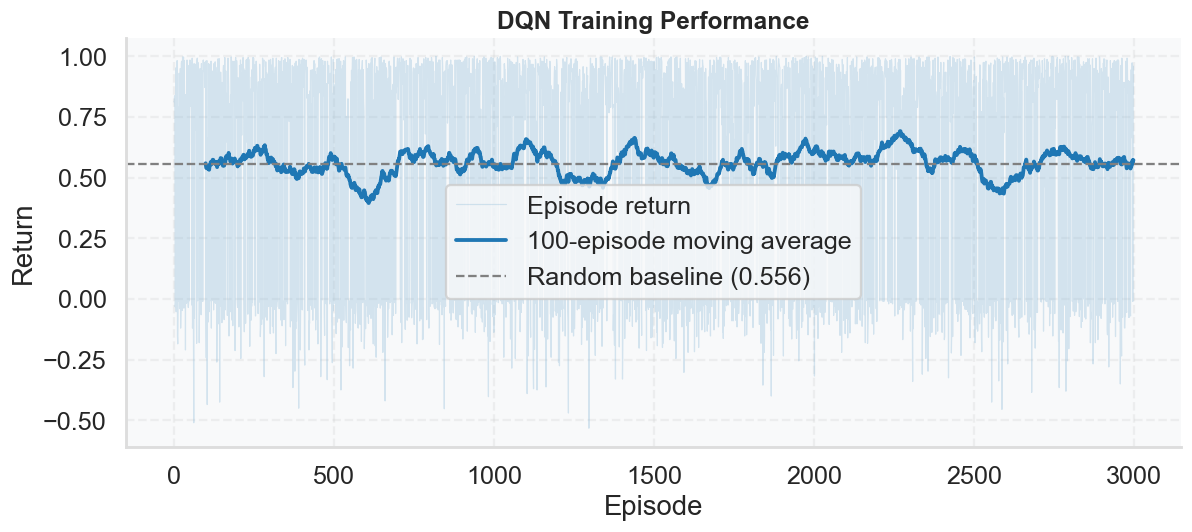

In [17]:
# DQN training return curve
window = 100
ma_returns = moving_average(final_metrics_b['returns'], window)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    final_metrics_b['returns'],
    color=LIGHT_BLUE, alpha=0.3, linewidth=0.8, label='Episode return'
)
ax.plot(
    range(window - 1, len(final_metrics_b['returns'])),
    ma_returns,
    color=BLUE, linewidth=2.5, label=f'{window}-episode moving average'
)
ax.axhline(clinical_rand_mean, color='gray', linestyle='--', linewidth=1.5,
           label=f'Random baseline ({clinical_rand_mean:.3f})')

ax.set_xlabel('Episode')
ax.set_ylabel('Return')
ax.set_title('DQN Training Performance', fontsize=16, fontweight='bold')
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_dqn_returns.png', bbox_inches='tight')
plt.show()

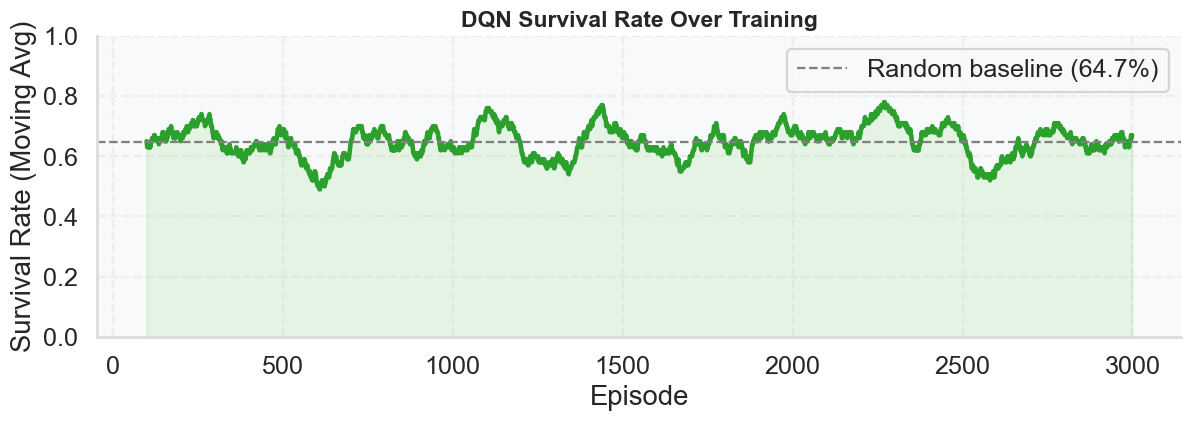

In [18]:
# Survival rate over training
ma_surv = moving_average([float(s) for s in final_metrics_b['survivals']], window)

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    range(window - 1, len(final_metrics_b['survivals'])),
    ma_surv,
    color=GREEN, linewidth=3
)
ax.fill_between(
    range(window - 1, len(final_metrics_b['survivals'])),
    ma_surv, alpha=0.2, color=LIGHT_GREEN
)
ax.axhline(clinical_rand_surv, color='gray', linestyle='--', linewidth=1.5,
           label=f'Random baseline ({clinical_rand_surv:.1%})')

ax.set_xlabel('Episode')
ax.set_ylabel('Survival Rate (Moving Avg)')
ax.set_title('DQN Survival Rate Over Training', fontsize=15, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_dqn_survival.png', bbox_inches='tight')
plt.show()

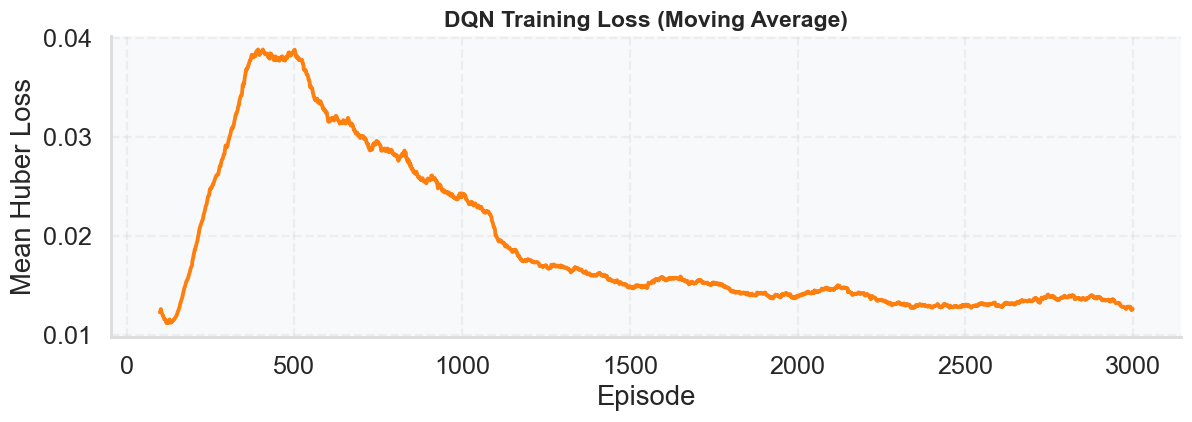

In [19]:
# Training loss curve
ma_loss = moving_average(final_metrics_b['losses'], window)

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    range(window - 1, len(final_metrics_b['losses'])),
    ma_loss,
    color=ORANGE, linewidth=2.5
)

ax.set_xlabel('Episode')
ax.set_ylabel('Mean Huber Loss')
ax.set_title('DQN Training Loss (Moving Average)', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_dqn_loss.png', bbox_inches='tight')
plt.show()

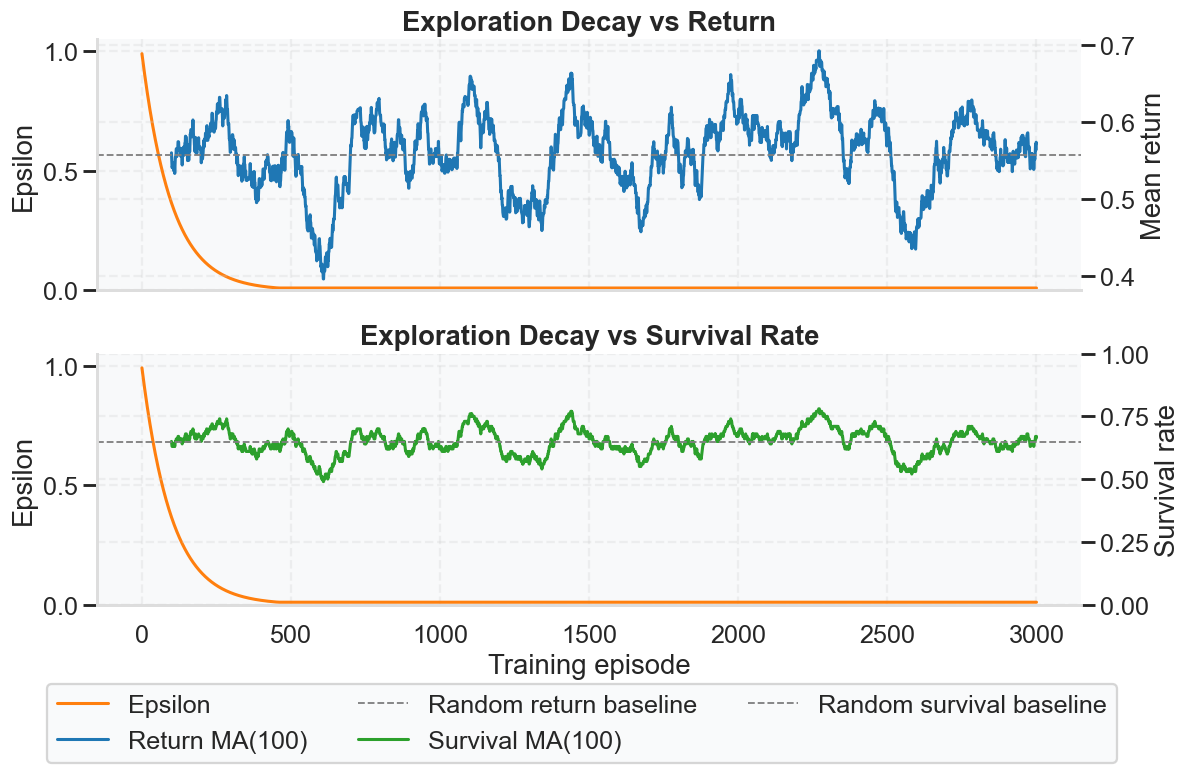

In [26]:
# Exploration vs exploitation-------------------------------------------------------------------------------------------------------------------------
window = 100

# Returns and survivals are observed in training, the variables can be noisy so we use a moving average to visualise the underlying trends more clearly.
# Epsilon is defined by the algorithm and is deterministic, so we plot it directly without smoothing. 
returns_ma = moving_average(final_metrics_b['returns'], window)
survival_ma = moving_average(final_metrics_b['survivals'], window)
epsilons = np.array(final_metrics_b['epsilons']) 

episodes = np.arange(1, len(epsilons) + 1)
ma_episodes = np.arange(window, len(epsilons) + 1)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Panel 1: epsilon and return
ax1 = axes[0]
ax1.plot(
    episodes,
    epsilons,
    color=ORANGE,
    linewidth=2,
    label='Epsilon'
)
ax1.set_ylabel('Epsilon')
ax1.set_ylim(0, 1.05)

ax1b = ax1.twinx()
ax1b.plot(
    ma_episodes,
    returns_ma,
    color=BLUE,
    linewidth=2,
    label=f'Return MA({window})'
)
ax1b.axhline(
    clinical_rand_mean,
    color='gray',
    linestyle='--',
    linewidth=1.2,
    label='Random return baseline'
)
ax1b.set_ylabel('Mean return')

ax1.set_title('Exploration Decay vs Return', fontweight='bold')


# Panel 2: epsilon and survival
ax2 = axes[1]
ax2.plot(
    episodes,
    epsilons,
    color=ORANGE,
    linewidth=2,
    label='Epsilon'
)
ax2.set_ylabel('Epsilon')
ax2.set_xlabel('Training episode')
ax2.set_ylim(0, 1.05)

ax2b = ax2.twinx()
ax2b.plot(
    ma_episodes,
    survival_ma,
    color=GREEN,
    linewidth=2,
    label=f'Survival MA({window})'
)
ax2b.axhline(
    clinical_rand_surv,
    color='gray',
    linestyle='--',
    linewidth=1.2,
    label='Random survival baseline'
)
ax2b.set_ylabel('Survival rate')
ax2b.set_ylim(0, 1)

ax2.set_title('Exploration Decay vs Survival Rate', fontweight='bold')


# Single shared legend
handles = []
labels = []

for ax in [ax1, ax1b, ax2, ax2b]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=True
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(f'{PLOTS_DIR}/configB_epsilon_vs_performance.png', bbox_inches='tight')
plt.show()

In [ ]:
# Average intensity of treatments over time (for the final agent)-------------------------------------------------------------------------------------------------------
# Objetive: evaluate if the agent learned how to prevent excessive treatment.

# Info from the environment:
# Action space      : Discrete(25) — vasopressor × IV fluid dose levels
#                     action = vasopressor_level * 5 + fluid_level
#                     evels 0..4 map to [none, low, medium, high, very high]



---
## 2. Failure Mode Analysis

Each wrapper introduces a distinct clinical failure mode. Here we assess the trained DQN's robustness by stratifying evaluation performance by wrapper activation, and by varying each wrapper's intensity while holding the others fixed.

In [26]:
# Stratified performance: noisy vs. clean, missing vs. complete, acute vs. not
eval_metrics_b = evaluate_policy_b(final_agent, n_episodes=2000, seed=SEED)

returns_arr = np.array(eval_metrics_b.episode_returns)
noisy_mask   = np.array(eval_metrics_b.noisy_flags)
missing_mask = np.array(eval_metrics_b.missing_flags)
acute_mask   = np.array(eval_metrics_b.acute_flags)

def strat_stats(mask, label):
    sel = returns_arr[mask]
    print(f'{label:30s} n={mask.sum():4d}  return={np.mean(sel):.4f}  surv={np.mean(sel>0):.1%}')

print('Stratified DQN evaluation (2000 episodes):')
print('-' * 65)
strat_stats(noisy_mask,         'Noisy episodes')
strat_stats(~noisy_mask,        'Clean episodes')
print()
strat_stats(missing_mask,       'Missing-obs episodes')
strat_stats(~missing_mask,      'Complete-obs episodes')
print()
strat_stats(acute_mask,         'Acute-event episodes')
strat_stats(~acute_mask,        'No-acute episodes')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Stratified DQN evaluation (2000 episodes):
-----------------------------------------------------------------
Noisy episodes                 n= 299  return=0.5811  surv=67.6%
Clean episodes                 n=1701  return=0.5708  surv=65.4%

Missing-obs episodes           n= 298  return=0.5719  surv=66.1%
Complete-obs episodes          n=1702  return=0.5724  surv=65.7%

Acute-event episodes           n= 176  return=-0.0888  surv=0.0%
No-acute episodes              n=1824  return=0.6361  surv=72.1%


In [27]:
# Sensitivity: vary malfunction_prob (EpisodicNoisyObsEnv)
noise_probs = [0.0, 0.05, 0.15, 0.30, 0.50]
noise_results = []

for prob in noise_probs:
    m = evaluate_policy_b(final_agent, n_episodes=500, seed=SEED, malfunction_prob=prob).summary()
    noise_results.append({'malfunction_prob': prob, **m})
    print(f'malfunction_prob={prob:.2f}  return={m["mean_return"]:.4f}  surv={m["survival_rate"]:.1%}')

noise_df = pd.DataFrame(noise_results)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
malfunction_prob=0.00  return=0.5948  surv=68.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
malfunction_prob=0.05  return=0.5643  surv=65.6%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
malfunction_prob=0.15  return=0.5475  surv=63.4%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
malfunction_prob=0.30  return=0.5704  surv=66.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
malfunction_prob=0.50  return=0.5920  surv=68.4%


In [28]:
# Sensitivity: vary missing_prob (EpisodicMissingObsEnv)
missing_probs = [0.0, 0.05, 0.15, 0.30, 0.50]
missing_results = []

for prob in missing_probs:
    m = evaluate_policy_b(final_agent, n_episodes=500, seed=SEED, missing_prob=prob).summary()
    missing_results.append({'missing_prob': prob, **m})
    print(f'missing_prob={prob:.2f}  return={m["mean_return"]:.4f}  surv={m["survival_rate"]:.1%}')

missing_df = pd.DataFrame(missing_results)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
missing_prob=0.00  return=0.5686  surv=65.2%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
missing_prob=0.05  return=0.5535  surv=63.4%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
missing_prob=0.15  return=0.5475  surv=63.4%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
missing_prob=0.30  return=0.5416  surv=63.2%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
missing_prob=0.50  return=0.5319  surv=61.4%


In [29]:
# Sensitivity: vary event_prob (AcuteEventEnv)
event_probs = [0.0, 0.005, 0.01, 0.02, 0.05]
event_results = []

for prob in event_probs:
    m = evaluate_policy_b(final_agent, n_episodes=500, seed=SEED, event_prob=prob).summary()
    event_results.append({'event_prob': prob, **m})
    print(f'event_prob={prob:.3f}  return={m["mean_return"]:.4f}  surv={m["survival_rate"]:.1%}')

event_df = pd.DataFrame(event_results)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
event_prob=0.000  return=0.6403  surv=72.6%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
event_prob=0.005  return=0.5920  surv=68.2%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
event_prob=0.010  return=0.5475  surv=63.4%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
event_prob=0.020  return=0.5496  surv=62.8%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
event_prob=0.050  return=0.4169  surv=47.8%


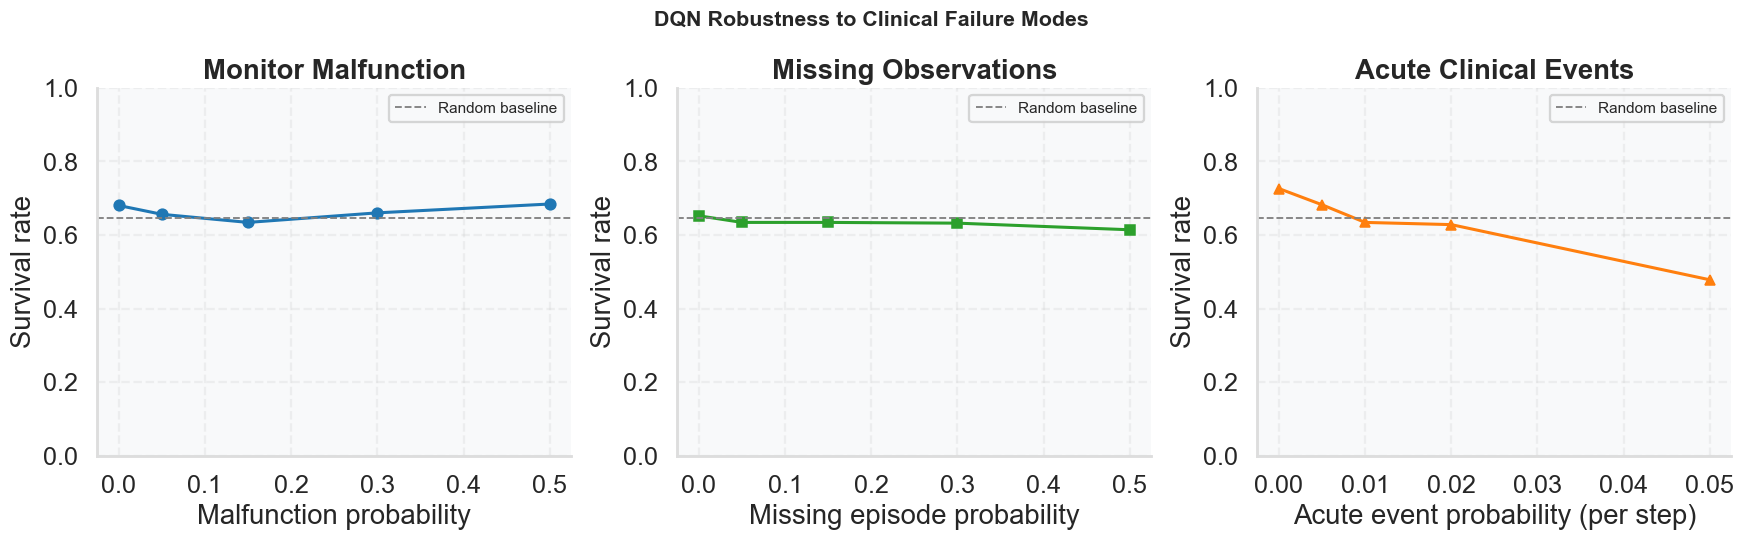

In [30]:
# Plot: survival rate vs. wrapper intensity for all three failure modes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(noise_df['malfunction_prob'],  noise_df['survival_rate'],   'o-', color=BLUE,   linewidth=2, markersize=7)
axes[0].set_title('Monitor Malfunction', fontweight='bold')
axes[0].set_xlabel('Malfunction probability')
axes[0].set_ylabel('Survival rate')
axes[0].set_ylim(0, 1)

axes[1].plot(missing_df['missing_prob'],    missing_df['survival_rate'], 's-', color=GREEN,  linewidth=2, markersize=7)
axes[1].set_title('Missing Observations', fontweight='bold')
axes[1].set_xlabel('Missing episode probability')
axes[1].set_ylabel('Survival rate')
axes[1].set_ylim(0, 1)

axes[2].plot(event_df['event_prob'],        event_df['survival_rate'],   '^-', color=ORANGE, linewidth=2, markersize=7)
axes[2].set_title('Acute Clinical Events', fontweight='bold')
axes[2].set_xlabel('Acute event probability (per step)')
axes[2].set_ylabel('Survival rate')
axes[2].set_ylim(0, 1)

for ax in axes:
    ax.axhline(clinical_rand_surv, color='gray', linestyle='--', linewidth=1.2, label='Random baseline')
    ax.legend(fontsize=10)

fig.suptitle('DQN Robustness to Clinical Failure Modes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_failure_mode_sensitivity.png', bbox_inches='tight')
plt.show()

---
## 3. Final Performance Summary

In [31]:
comparison_df_b = pd.DataFrame([
    {
        'Algorithm':        'Random',
        'Mean Return':      clinical_rand_mean,
        'Survival Rate':    clinical_rand_surv,
        'Return Std':       float(np.std(clinical_rand_returns)),
        'Convergence Ep':   float('nan'),
    },
    {
        'Algorithm':        'DQN (Double)',
        'Mean Return':      dqn_summary['return_mean'],
        'Survival Rate':    dqn_summary['survival_mean'],
        'Return Std':       dqn_summary['return_std'],
        'Convergence Ep':   dqn_speed,
    },
])

comparison_df_b

,Algorithm,Mean Return,Survival Rate,Return Std,Convergence Ep
0,Random,0.552845,0.6470,0.481550,NaN
1,DQN (Double),0.578453,0.6646,0.007547,5.0


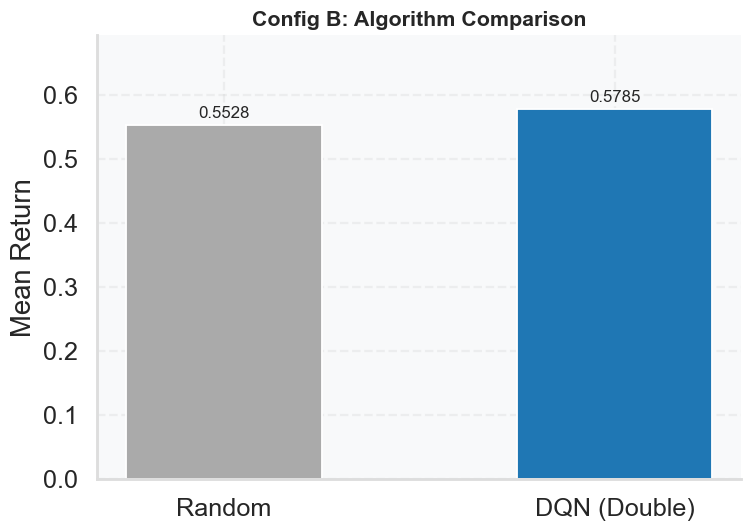

In [32]:
# Bar chart: mean return comparison
fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#aaaaaa', BLUE]
bars = ax.bar(
    comparison_df_b['Algorithm'],
    comparison_df_b['Mean Return'],
    color=colors,
    width=0.5,
    edgecolor='white',
    linewidth=1.2,
)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=11)

ax.set_ylabel('Mean Return')
ax.set_title('Config B: Algorithm Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(comparison_df_b['Mean Return']) * 1.2)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_final_comparison.png', bbox_inches='tight')
plt.show()

### Summary

- **Random baseline** establishes the performance floor on the clinical environment with all three wrappers active.
- **Double DQN** successfully learns a treatment policy from continuous physiological observations, beating the random baseline. It demonstrates robustness to moderate levels of observation noise and missing features, while the irreducible stochasticity from acute clinical events provides an inherent upper bound on achievable survival rate.
- The failure-mode sensitivity analysis confirms that performance degrades gracefully as wrapper intensity increases — the agent is not brittle to the clinical realism injected by Config B.